# CNN전이학습_data_augmentation
* 전이학습: 사전에 훈련된 모델을 가져와서 사용하는 것
* data_agmentation: 이미지 데이터의 경우 데이터가 적어서 확보가 어려움, 비쌈, 기존 이미지데이터에 변형을 가해서 데이터 수를 늘리는 작업(회전, 확대, 축소, 자르기)
# Image Augmentation
* 학습데이터 부족을 해결하기 위해서 이미지에 변형을 가해 새로운 이미지를 만들어 주는 것

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.preprocessing.image import img_to_array, ImageDataGenerator, array_to_img, load_img

In [3]:
image = load_img("./data/bird.jpg")
image_array = img_to_array(image)
image_array.shape

(703, 454, 3)

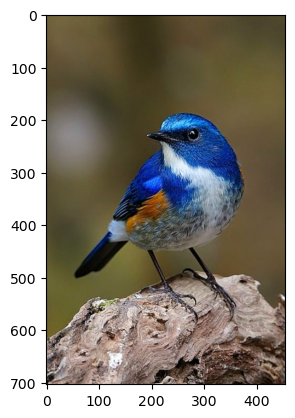

In [6]:
plt.imshow(image)
plt.show()

# Image Augmentation(이미지 증폭)

In [7]:
imggen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.3,
        height_shift_range=0.2,
        shear_range=0.6,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest')

# 차원 늘리기

In [8]:
(1,) + image_array.shape

(1, 703, 454, 3)

In [9]:
# image_array = image_array.reshape((1, 703, 454, 3))
image_array = image_array.reshape((1,) + image_array.shape)

In [10]:
image_array.shape

(1, 703, 454, 3)

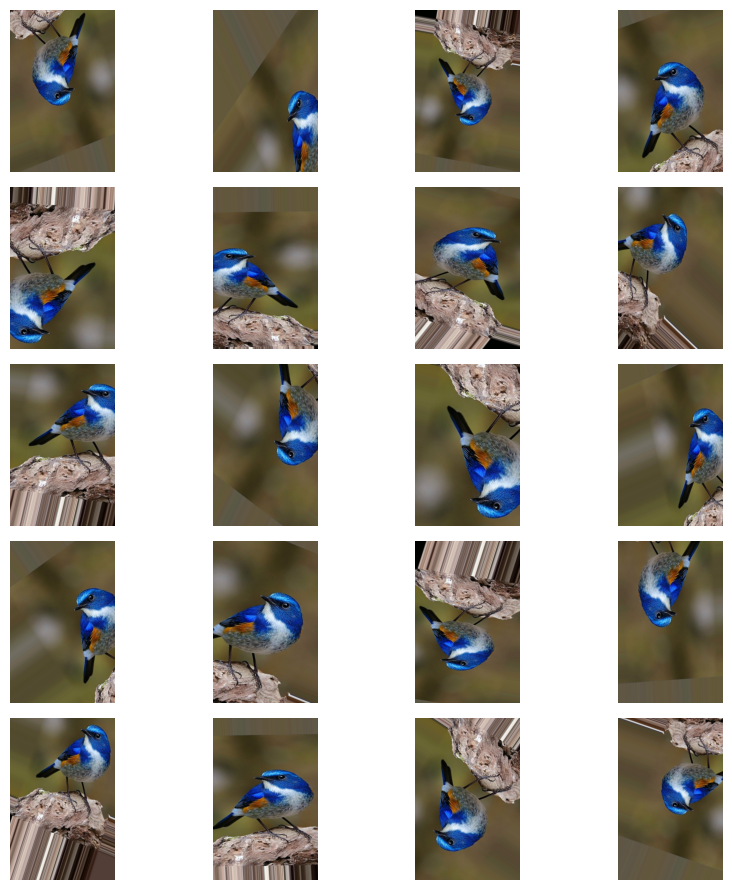

In [11]:
fig, axes = plt.subplots(5, 4, figsize=(9,9))
axes = axes.ravel()
for i, batch in enumerate(imggen.flow(image_array, batch_size=1)):
    if i >= 20:
        break
    augmented_image = array_to_img(batch[0])
    axes[i].imshow(augmented_image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# image_augemtation 을 이용한 개/고양이 분류 모델 만들기

In [29]:
# 데이터 로드
train_dir = "./data/train/"
valid_dir = "./data/validation/"
batch_size = 16  # 한 번에 불러오는 사진의 개수, 분석 모델에 따라서 16, 32 사이로 지정
image_size = (224, 224) # 모델의 입력 크기에 맞춤

In [30]:
# 이미지 증강
train_aug = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.3,
        height_shift_range=0.2,
        shear_range=0.6,
        zoom_range=0.3,
#         horizontal_flip=True,
#         vertical_flip=True,
        fill_mode='nearest')

valid_aug = ImageDataGenerator(rescale=1./255)

# 이미지 제너레이터
train_gen = train_aug.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
            )

valid_gen = valid_aug.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
            )

X_batch, y_batch = next(train_gen)
print(X_batch.shape)
print(y_batch.shape)
print(train_gen.class_indices)

Found 385 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


# CNN을 이용한 개/고양이 분류

In [31]:
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [32]:
cnn_model = Sequential()
cnn_model.add(Input(shape=(224, 224, 3)))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.25))
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(2, activation='softmax'))
cnn_model.summary()
              

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,815,266 (10.74 MB)

 Trainable params: 2,815,266 (10.74 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 259ms/step - accuracy: 0.5091 - loss: 0.7021 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.5195 - loss: 0.6942 - val_accuracy: 0.5204 - val_loss: 0.6903
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.5065 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 4/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.5273 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.5273 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 6/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.5273 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 7/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.5273 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 8/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.5195 - loss: 0.6933 -

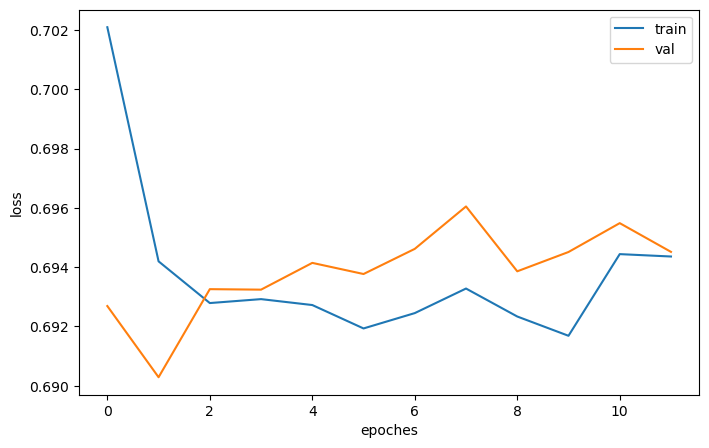

In [33]:
cnn_model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
model_path = "./model/CNN_catndog.keras"
chechpoint = ModelCheckpoint(filepath=model_path, save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
cnn_history = cnn_model.fit(train_gen, validation_data=valid_gen, epochs=1000,
                   callbacks=[chechpoint, early_stop])
plt.figure(figsize=(8,5))
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.xlabel("epoches")
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [34]:
import tensorflow as tf

In [35]:
cnn_model2 = Sequential()
cnn_model2.add(Input(shape=(224, 224, 3)))
cnn_model2.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model2.add(MaxPooling2D(2,2))
cnn_model2.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
cnn_model2.add(MaxPooling2D(2,2))
cnn_model2.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model2.add(MaxPooling2D(2,2))
cnn_model2.add(Flatten())
cnn_model2.add(Dense(128, activation='relu'))
cnn_model2.add(Dropout(0.25))
cnn_model2.add(Dense(64, activation='relu'))
cnn_model2.add(Dense(2, activation='softmax'))
cnn_model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,815,266 (10.74 MB)

 Trainable params: 2,815,266 (10.74 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
cus_opt = tf.keras.optimizers.Adam(learning_rate=1e-4)

Epoch 1/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step - accuracy: 0.5013 - loss: 0.7024 - val_accuracy: 0.5306 - val_loss: 0.6834
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.5273 - loss: 0.6906 - val_accuracy: 0.5000 - val_loss: 0.6856
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.5429 - loss: 0.6882 - val_accuracy: 0.5510 - val_loss: 0.6797
Epoch 4/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.5403 - loss: 0.6893 - val_accuracy: 0.5714 - val_loss: 0.6763
Epoch 5/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.5351 - loss: 0.6880 - val_accuracy: 0.5000 - val_loss: 0.6740
Epoch 6/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.5403 - loss: 0.6857 - val_accuracy: 0.5102 - val_loss: 0.6735
Epoch 7/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - accuracy: 0.5273 - loss: 0.6884 - val_accuracy: 0.5000 - val_loss: 0.6711
Epoch 8/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.5481 - loss: 0.6838 - 

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.6961 - loss: 0.5669 - val_accuracy: 0.7041 - val_loss: 0.5618
Epoch 51/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.7221 - loss: 0.5457 - val_accuracy: 0.7143 - val_loss: 0.5593
Epoch 52/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.7195 - loss: 0.5533 - val_accuracy: 0.7041 - val_loss: 0.5704
Epoch 53/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.7429 - loss: 0.5366 - val_accuracy: 0.7347 - val_loss: 0.5451
Epoch 54/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.7091 - loss: 0.5407 - val_accuracy: 0.6939 - val_loss: 0.5439
Epoch 55/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.7247 - loss: 0.5337 - val_accuracy: 0.6327 - val_loss: 0.6217
Epoch 56/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.7221 - loss: 0.5288 - val_accuracy: 0.7245 - val_loss: 0.5829
Epoch 57/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.7091 - loss: 0.5563 - val_ac

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.7766 - loss: 0.4603 - val_accuracy: 0.6735 - val_loss: 0.5459
Epoch 100/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.7792 - loss: 0.4412 - val_accuracy: 0.7143 - val_loss: 0.5405
Epoch 101/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.7195 - loss: 0.5369 - val_accuracy: 0.6020 - val_loss: 0.6931
Epoch 102/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.7351 - loss: 0.5348 - val_accuracy: 0.7041 - val_loss: 0.5898
Epoch 103/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.7610 - loss: 0.5043 - val_accuracy: 0.6837 - val_loss: 0.5725
Epoch 104/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.7584 - loss: 0.4747 - val_accuracy: 0.7041 - val_loss: 0.5683
Epoch 105/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.7584 - loss: 0.4616 - val_accuracy: 0.6837 - val_loss: 0.6307
Epoch 106/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.7896 - loss: 0.4467 -

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.8390 - loss: 0.3787 - val_accuracy: 0.7041 - val_loss: 0.5895
Epoch 149/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.8078 - loss: 0.3876 - val_accuracy: 0.6939 - val_loss: 0.7781
Epoch 150/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.7870 - loss: 0.4096 - val_accuracy: 0.6531 - val_loss: 0.7592
Epoch 151/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.8130 - loss: 0.3947 - val_accuracy: 0.6939 - val_loss: 0.6482
Epoch 152/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.8260 - loss: 0.4145 - val_accuracy: 0.6735 - val_loss: 0.6644
Epoch 153/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.8312 - loss: 0.3727 - val_accuracy: 0.6531 - val_loss: 0.8061
Epoch 154/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.8026 - loss: 0.4191 - val_accuracy: 0.7041 - val_loss: 0.5821
Epoch 155/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.8364 - loss: 0.3759 -

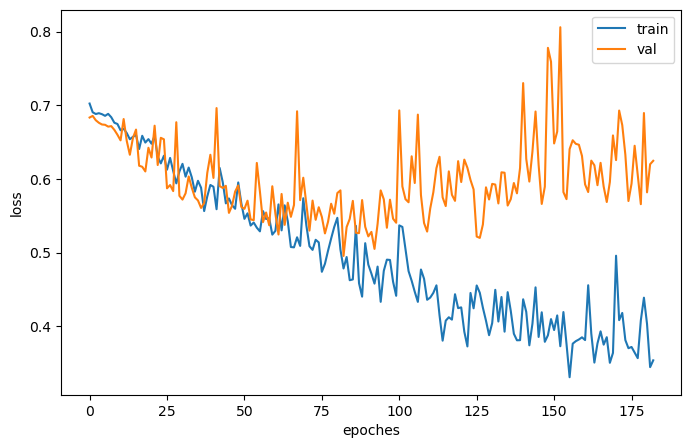

In [37]:
cnn_model2.compile(loss="categorical_crossentropy", optimizer=cus_opt, metrics=['accuracy'])
model_path = "./model/CNN_catndog2.keras"
chechpoint = ModelCheckpoint(filepath=model_path, save_best_only=True)
early_stop = EarlyStopping(patience=100, restore_best_weights=True)
cnn_history2 = cnn_model2.fit(train_gen, validation_data=valid_gen, epochs=1000,
                   callbacks=[chechpoint, early_stop])
plt.figure(figsize=(8,5))
plt.plot(cnn_history2.history['loss'])
plt.plot(cnn_history2.history['val_loss'])
plt.xlabel("epoches")
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step


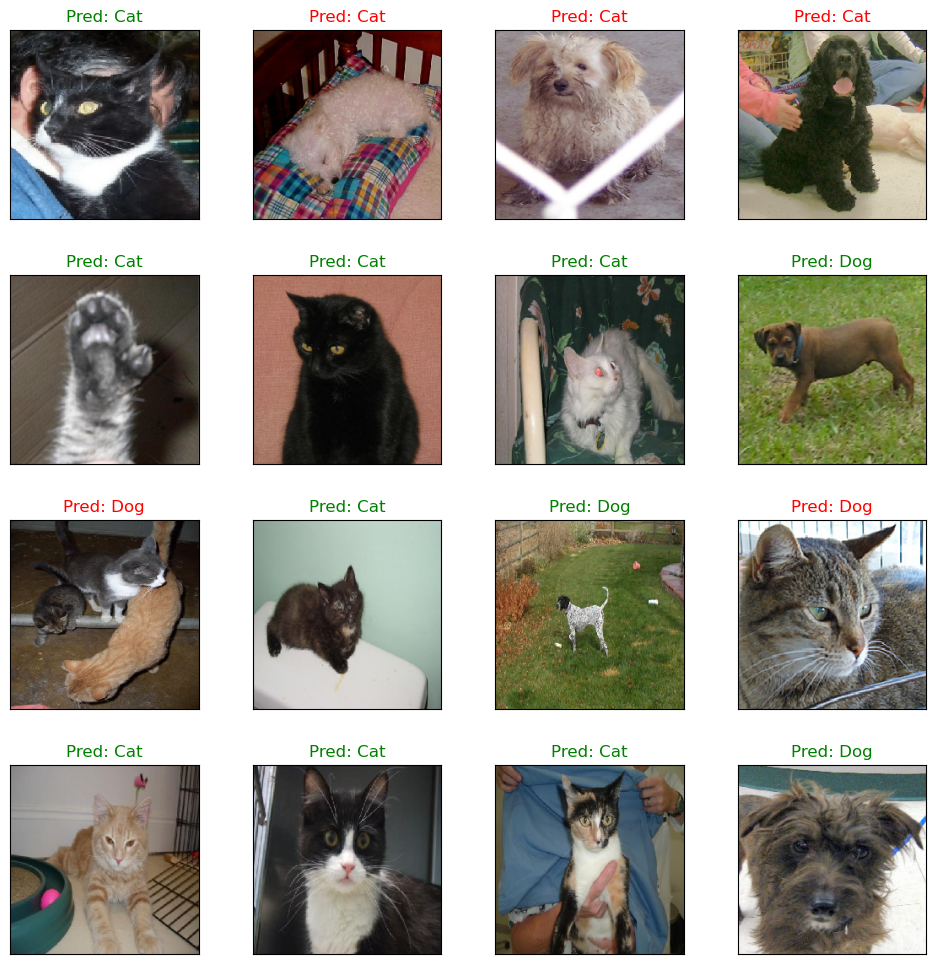


cnn_best_model평가 결과: Loss: 0.6340, Accuracy: 0.6875


In [38]:
# best 모델 로드
cnn_best_model = load_model("./model/CNN_catndog2.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

cnn_pred = cnn_best_model.predict(validation_batch)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = cnn_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\ncnn_best_model평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# 전이학습
* 사전에 훈련된 모델을 가지고 새로운 데이터를 넣어서 튜닝을 하거나 결과를 출력
* keras.applications에 있음.

# ResNet50
* ResNet50에 사용할 경우, rescale=1./255는 제거하고 preprocessing_function=preprocess_input을 사용
* Keras의 ResNet50은 입력 이미지를 BGR로 바꾸고 채널별 평균을 빼는 전처리를 필요로 하기 때문

In [32]:
import tensorflow as tf
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.preprocessing.image import img_to_array, ImageDataGenerator, array_to_img, load_img
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.applications import ResNet50, ResNet152V2
from tensorflow.keras.applications.resnet import preprocess_input

In [22]:
# 데이터 로드
train_dir = "./data/train/"
valid_dir = "./data/validation/"
batch_size = 16  # 한 번에 불러오는 사진의 개수, 분석 모델에 따라서 16, 32 사이로 지정
image_size = (224, 224) # 모델의 입력 크기에 맞춤

In [23]:
# ResNet50 맞는 이미지 증강기 (rescale제거 , preprocess_input 사용)
# 이미지 증강
train_aug = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=40,
        width_shift_range=0.3,
        height_shift_range=0.2,
        shear_range=0.6,
        zoom_range=0.3,
#         horizontal_flip=True,
#         vertical_flip=True,
        fill_mode='nearest')

valid_aug = ImageDataGenerator(preprocessing_function=preprocess_input)

# 이미지 제너레이터
train_gen = train_aug.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
            )

valid_gen = valid_aug.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
            )

X_batch, y_batch = next(train_gen)
print(X_batch.shape)
print(y_batch.shape)
print(train_gen.class_indices)

Found 385 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


In [24]:
base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=None, input_shape=(224, 224, 3), pooling='avg')

In [25]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [26]:
base_model.trainable = False
res50_model = Sequential()
res50_model.add(base_model)
res50_model.add(Dense(2, activation='softmax'))
res50_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [27]:
cus_opt = tf.keras.optimizers.Adam(learning_rate=1e-4)

In [ ]:
res50_model.compile(loss="categorical_crossentropy", optimizer=cus_opt, metrics=['accuracy'])
model_path = "./model/res50_model_catndog2.keras"
chechpoint = ModelCheckpoint(filepath=model_path, save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
res50_model_history = res50_model.fit(train_gen, validation_data=valid_gen, epochs=1000,
                   callbacks=[chechpoint, early_stop])

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

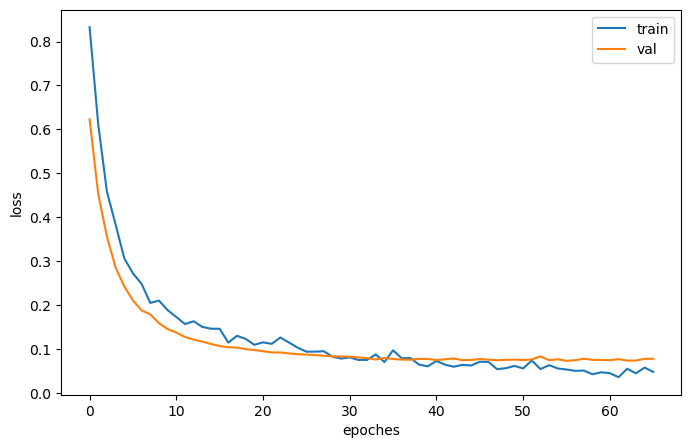

In [30]:
plt.figure(figsize=(8,5))
plt.plot(res50_model_history.history['loss'])
plt.plot(res50_model_history.history['val_loss'])
plt.xlabel("epoches")
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [34]:
from sklearn.metrics import accuracy_score

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 525ms/step

[전체 Validation Accuracy] 0.4592
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


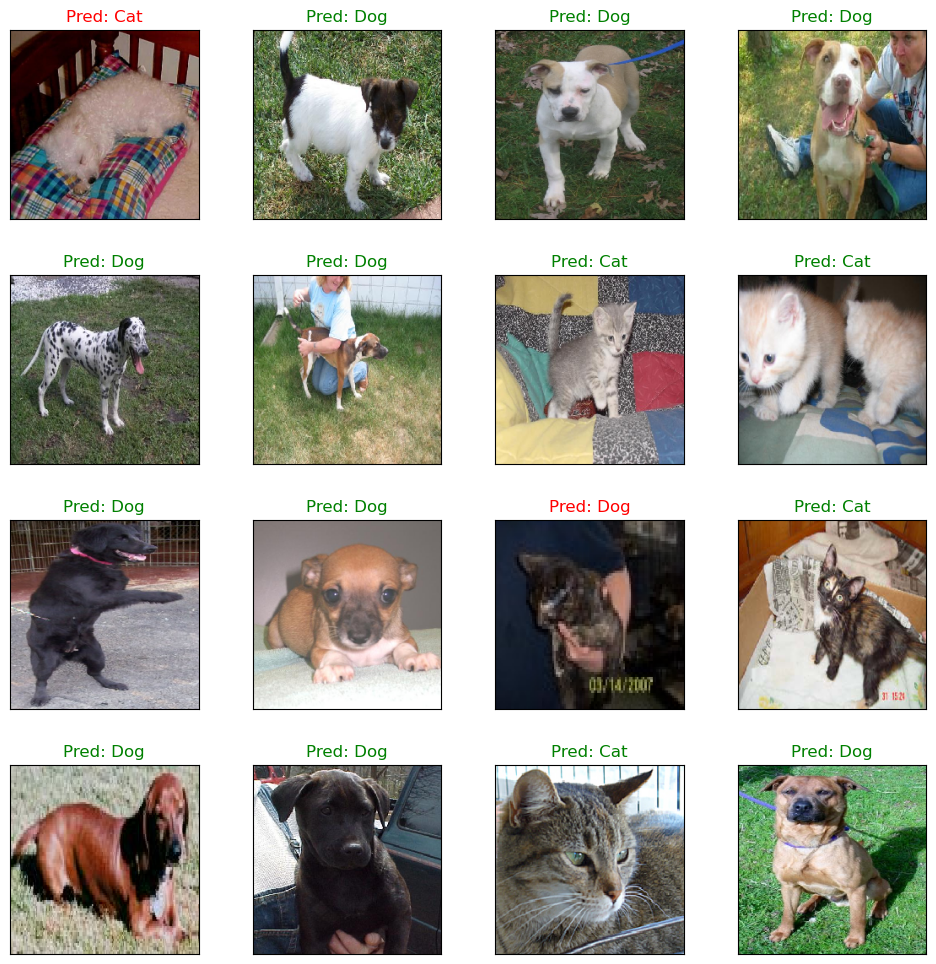

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 326ms/step - accuracy: 0.9694 - loss: 0.0728

[모델 평가 결과] Loss: 0.0728, Accuracy: 0.9694


In [38]:
# ✅ 모델 로드
res50_best_model = load_model("./model/res50_model_catndog2.keras")

# ✅ 클래스 이름 추출
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]

# ✅ 전체 validation 데이터로 예측
cnn_pred = res50_best_model.predict(valid_gen, verbose=1)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = valid_gen.classes  # 전체 정답

# ✅ 정확도 출력
acc = accuracy_score(true_values, pred_values)
print(f"\n[전체 Validation Accuracy] {acc:.4f}")

# ✅ 시각화용: 소량 배치만 가져오기
sample_batch, label_batch = next(valid_gen)
sample_pred = res50_best_model.predict(sample_batch)
sample_pred_values = np.argmax(sample_pred, axis=1)
sample_true_values = np.argmax(label_batch, axis=1)

# ✅ 시각화: 이미지 복구 후 출력
def deprocess_input(x):
    """ResNet의 preprocess_input을 반대로 적용 (BGR→RGB + 평균값 복원)"""
    x = x.copy()
    # ImageNet 평균값 (BGR 순)
    mean = [103.939, 116.779, 123.68]
    x[..., 0] += mean[0]  # B
    x[..., 1] += mean[1]  # G
    x[..., 2] += mean[2]  # R
    x = x[..., ::-1]  # BGR → RGB
    return np.clip(x / 255.0, 0, 1)  # matplotlib은 0~1 사이값을 기대함

# ✅ 이미지 시각화
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(hspace=0.3)
num_images = min(16, sample_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    img = deprocess_input(sample_batch[i])
    ax.imshow(img)
    pred_label = class_names[sample_pred_values[i]]
    true_label = class_names[sample_true_values[i]]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# ✅ 전체 평가
loss, acc = res50_best_model.evaluate(valid_gen, verbose=1)
print(f"\n[모델 평가 결과] Loss: {loss:.4f}, Accuracy: {acc:.4f}")